1️⃣ K-Means – Segmentação de Clientes (shopping)

Saving Mall_Customers.csv to Mall_Customers.csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Resumo por cluster:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        46.25               26.75                   18.35
1        25.19               41.09                   62.24
2        32.88               86.10                   81.53
3        39.87               86.10                   19.36
4        55.64               54.38                   48.85


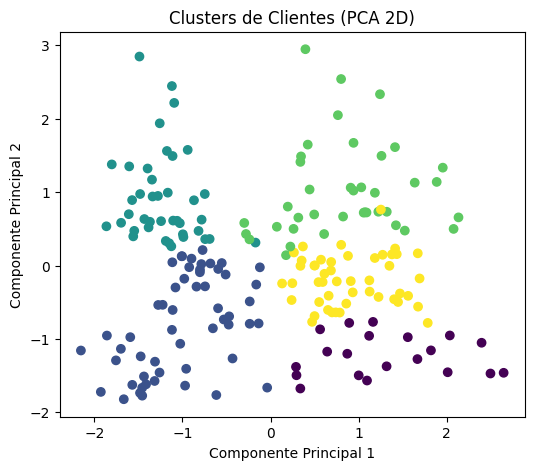

In [ ]:
# -----------------------------
# K-MEANS – Segmentação de Clientes
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# upload da base
from google.colab import files
uploaded = files.upload()  # selecionar Mall_Customers.csv

df = pd.read_csv("Mall_Customers.csv")

# visualizar dados
print(df.head())

# selecionar features
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# clustering
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nResumo por cluster:")
print(df.groupby("Cluster")[features].mean().round(2))

# PCA para visualização
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.title("Clusters de Clientes (PCA 2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

2️⃣ Isolation Forest – Detecção de Anomalias (fraude)

Saving creditcard.csv to creditcard.csv
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206

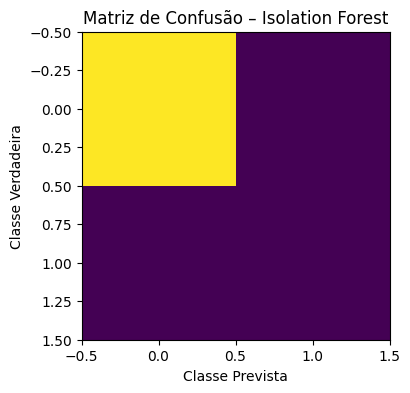

In [ ]:
# -----------------------------
# ISOLATION FOREST – Detecção de Anomalias
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import files
uploaded = files.upload()  # selecionar creditcard.csv

df = pd.read_csv("creditcard.csv")

print(df.head())

# remover coluna Class
X = df.drop(columns=["Class"])
y = df["Class"]

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# modelo
model = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42
)

model.fit(X_train)

# previsão
y_pred = model.predict(X_test)

# converter -1 para fraude
y_pred = np.where(y_pred == -1, 1, 0)

print(classification_report(y_test, y_pred))

# matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Matriz de Confusão – Isolation Forest")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Verdadeira")
plt.show()

3️⃣ Q-Learning – Controle Adaptativo de Semáforo

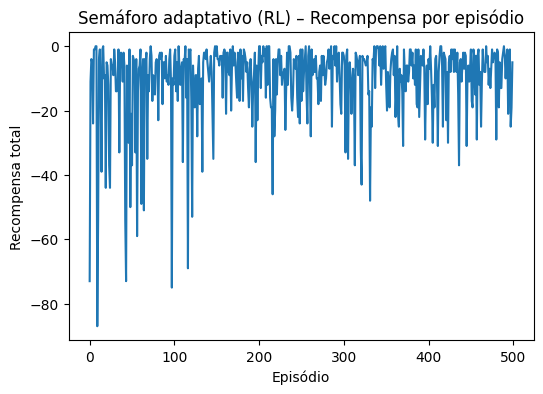

Q-table final:
[[ -1.36161378  -0.20998831   0.        ]
 [ -3.24922573  -1.69977333  -0.12273985]
 [ -6.4222183   -4.09383758  -1.79017181]
 [ -9.42295969  -5.90032992  -4.01664568]
 [-11.52983582  -9.10946591  -5.37104913]
 [-13.56482524 -12.26025763  -8.07126696]]


In [ ]:
# -----------------------------
# Q-LEARNING – Controle de Semáforo
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# estados de fila
states = [0,1,2,3,4,5]

# ações
actions = [0,1,2]  # 0 = verde curto, 1 = médio, 2 = longo

# tabela Q
q = np.zeros((len(states), len(actions)))

# parâmetros do aprendizado
alpha = 0.1
gamma = 0.9
epsilon = 0.2

episodes = 500

rewards = []

for ep in range(episodes):

    state = np.random.choice(states)
    total_reward = 0

    for step in range(20):

        # estratégia epsilon-greedy
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = np.argmax(q[state])

        # simulação da chegada de carros
        cars = np.random.randint(0,3)

        # cálculo do próximo estado (fila)
        next_state = state + cars - action

        # limitar estado entre 0 e 5
        next_state = max(0, min(5, next_state))

        # recompensa (quanto menor a fila melhor)
        reward = -next_state

        # atualização da Q-table
        q[state,action] = q[state,action] + alpha * (
            reward + gamma * np.max(q[next_state]) - q[state,action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

# gráfico de aprendizado
plt.figure(figsize=(6,4))
plt.plot(rewards)
plt.title("Semáforo adaptativo (RL) – Recompensa por episódio")
plt.xlabel("Episódio")
plt.ylabel("Recompensa total")
plt.show()

# tabela Q final
print("Q-table final:")
print(q)

## Comparação Conceitual entre Tipos de Aprendizado

Os três principais paradigmas de aprendizado de máquina possuem características distintas quanto ao tipo de dados utilizados, forma de aprendizado e objetivo do modelo.

| Característica | Aprendizado Supervisionado | Aprendizado Não Supervisionado | Aprendizado por Reforço |
|---|---|---|---|
| Existe variável alvo? | Sim | Não | Não diretamente |
| Existe rótulo nos dados? | Sim | Não | Não |
| Função de perda tradicional? | Sim (ex: MSE, Cross Entropy) | Não necessariamente | Não. O objetivo é maximizar a recompensa |
| Interação com ambiente? | Não | Não | Sim |
| Tipo de problema típico | Classificação e Regressão | Clustering e Detecção de Anomalias | Tomada de decisão sequencial |
| Exemplo de algoritmo | Regressão Linear, Random Forest, Redes Neurais | K-Means, PCA, Isolation Forest | Q-Learning, DQN |

### Interpretação

No **aprendizado supervisionado**, os modelos aprendem a partir de dados rotulados, ou seja, existe uma variável alvo conhecida que o modelo tenta prever. Esse tipo de abordagem é muito utilizado em problemas de classificação e regressão.

No **aprendizado não supervisionado**, não existem rótulos nos dados. O objetivo do algoritmo é identificar padrões ocultos ou estruturas nos dados, como agrupamentos ou anomalias. Exemplos incluem segmentação de clientes e detecção de comportamentos incomuns.

Já o **aprendizado por reforço** funciona de forma diferente, pois envolve um agente que interage com um ambiente ao longo do tempo. O agente executa ações, observa os resultados e recebe recompensas ou penalidades. Com base nesse feedback, o agente aprende uma política que maximiza a recompensa acumulada.

Portanto, enquanto o aprendizado supervisionado foca em **previsão**, o aprendizado não supervisionado busca **descoberta de padrões**, e o aprendizado por reforço trata de **tomada de decisão sequencial em ambientes dinâmicos**.